# Texas Childcare: Compliance Records vs. Family Experience
## Notebook 03 — Model 2B: Individual Review Text (Center-Aligned)

**Author:** Rakesh Chandrasekaran
**Program:** Professional Certificate in ML and AI, UC Berkeley
**Date:** June 2026

---

## Research Question

**Do Texas HHSC compliance records and families' Google reviews agree on which daycare centers are high quality — and can a parent rely on compliance records alone to make an informed childcare decision?**

This project builds two predictive models. The first uses HHSC regulatory inspection features; the second uses the text of families' own Google reviews. Both models predict a center's Google star rating — both the exact rating (regression) and whether a center is rated excellent by families (4.5 stars and above, classification). Comparing the two models reveals how closely compliance data and family experience track each other, and whether a parent consulting only inspection records would reach the same conclusion as one who reads reviews.


---

## Cities in Scope
Austin · Houston · San Antonio · Dallas · Fort Worth

---

### This Notebook
Trains TF-IDF models on individual reviews to test whether individual review text can predict center-level quality. Two tracks are compared: Model 2B.1 uses an individual review split with `review_rating >= 4` labels (alternative approach, Sections 1 and 2), and Model 2B.2 uses a center-aligned split with `google_rating >= 4.5` labels — the same target as Model 1 (primary approach, Sections 3 to 5). Individual review predictions are aggregated to center level for direct comparison with Model 1 and Model 2A. Saves outputs to `model2b_outputs.pkl`.

### Notebook Structure
0. Setup, Data Loading and Validation
    - 0.1 Class Distribution Comparison (Model 1 vs Model 2B)
    - 0.2 Split Validation
1. Model 2B.1 — Baselines
    - 1.1 DummyClassifier Baseline
    - 1.2 Naive Bayes Baseline
2. Model 2B.1 — Individual Review Classification (Alternative Approach)
    - 2.1 TF-IDF + LR (2 rounds, word coefficients in 2.1.7)
    - 2.2 TF-IDF + XGBoost (comparison, 1 round)
    - 2.3 Classification Summary
    - 2.4 ROC Curve Overlay
    - 2.5 Why Model 2B.2 is Needed
3. Model 2B.2 — Individual Reviews with Center-Aligned Split (Primary)
    - 3.1 Center-Aligned Data Setup
    - 3.2 Baselines (DummyClassifier, Naive Bayes)
    - 3.3 TF-IDF + Ridge Regression (3 rounds)
    - 3.4 TF-IDF + LR Classification (2 rounds)
    - 3.5 Aggregate Predictions to Center Level
4. Model 2B.2 — Center-Level Visualisations
    - 4.1 ROC Curve Overlay
    - 4.2 Predicted vs Actual Scatter
    - 4.3 Word Predictors: Center-Level Quality
5. Model 2B.2 — Center-Level Error Analysis
    - 5.1 Misclassified Centers (Simple Mean)
    - 5.2 Center-Level Confusion Matrix
6. Save Outputs — Handoff to Notebook 04
    - Saves model2b_outputs.pkl: metrics, predictions, center labels

## 0. Setup, Data Loading and Validation

In [1]:
# ── Libraries ────────────────────────────────────────────────────────────
import os, pickle
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

# ── Scikit-learn: pipelines, model selection, metrics ───────────────────
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, f1_score,
    RocCurveDisplay, ConfusionMatrixDisplay,
    mean_squared_error, mean_absolute_error, r2_score
)

# ── XGBoost ───────────────────────────────────────────────────────────────
from xgboost import XGBClassifier

# ── Reproducibility and paths ─────────────────────────────────────────────
SEED         = 42
np.random.seed(SEED)
THRESHOLD    = 4.5   # center-level: google_rating >= 4.5 = HIGH_RATED
M2_THRESHOLD = 4     # individual review: review_rating >= 4 = HIGH_RATED

# ── Directory configuration ───────────────────────────────────────────────
BASE_DIR  = os.getcwd()
IMAGE_DIR = os.path.join(BASE_DIR, 'images', 'models')
os.makedirs(IMAGE_DIR, exist_ok=True)
PROC_DIR  = os.path.join(BASE_DIR, 'data', 'processed')

# ── Load datasets (exported by Notebook 00, Section 13.1) ─────────────────
df_model1 = pd.read_csv(os.path.join(PROC_DIR, 'model1_dataset.csv'))
df_model2 = pd.read_csv(os.path.join(PROC_DIR, 'model2_reviews.csv'))

# ── Load Model 1 outputs (exported by Notebook 01, Section 5) ─────────────
with open(os.path.join(PROC_DIR, 'model1_outputs.pkl'), 'rb') as f:
    m1 = pickle.load(f)
rmse_xgb    = m1['rmse_xgb']
m1_auc      = m1['m1_auc']
y1_pred_prob = m1['y1_pred_prob']
y1_clf_test  = m1['y1_clf_test']

# ── Load Model 2A outputs (exported by Notebook 02, Section 5) ────────────
with open(os.path.join(PROC_DIR, 'model2a_outputs.pkl'), 'rb') as f:
    m2a = pickle.load(f)
rmse_m2a    = m2a['rmse_m2a']
m2a_clf_auc = m2a['m2a_clf_auc']

# ── Model 2B individual review split ──────────────────────────────────────
# Note: train_op_ids/test_op_ids loaded from pkl — guaranteed identical split to Model 1
train_center_ids = set(m1['train_op_ids'])
test_center_ids  = set(m1['test_op_ids'])

df_model2['recency_weight'] = df_model2['recency_weight'].fillna(df_model2['recency_weight'].mean())
X2     = df_model2['review_text']
X2_ids = df_model2['OPERATION_ID']
X2_rw  = df_model2['recency_weight']
y2_raw = df_model2['review_rating']

from sklearn.model_selection import train_test_split
X2_train, X2_test, X2_ids_train, X2_ids_test, X2_rw_train, X2_rw_test, y2_raw_train, y2_raw_test = train_test_split(
    X2, X2_ids, X2_rw, y2_raw, test_size=0.2, random_state=SEED, stratify=(y2_raw >= M2_THRESHOLD))
y2_train = (y2_raw_train >= M2_THRESHOLD).astype(int)
y2_test  = (y2_raw_test  >= M2_THRESHOLD).astype(int)

print(f'Datasets loaded: {len(df_model1):,} centers | {len(df_model2):,} reviews')
print(f'Model 1: RMSE={rmse_xgb:.4f}  AUC={m1_auc:.4f}')
print(f'Model 2A: RMSE={rmse_m2a:.4f}  AUC={m2a_clf_auc:.4f}')
print(f'Center split: {len(train_center_ids):,} train | {len(test_center_ids):,} test')
print(f'Individual reviews: {len(X2_train):,} train | {len(X2_test):,} test')

Datasets loaded: 1,697 centers | 7,550 reviews
Model 1: RMSE=0.5555  AUC=0.6441
Model 2A: RMSE=0.4477  AUC=0.8418
Center split: 1,357 train | 340 test
Individual reviews: 6,040 train | 1,510 test


In [2]:
# Pre-flight check — confirm all Notebook 01 and 02 inputs are available
required_m1 = ['rmse_xgb', 'm1_auc', 'y1_pred_prob', 'y1_clf_test', 'train_op_ids', 'test_op_ids']
required_m2a = ['rmse_m2a', 'm2a_clf_auc']
required_frames = {'df_model1': df_model1, 'df_model2': df_model2}

for key in required_m1:
    status = 'OK' if key in m1 else 'MISSING'
    print(f"  m1['{key}']  {status}")
for key in required_m2a:
    status = 'OK' if key in m2a else 'MISSING'
    print(f"  m2a['{key}']  {status}")
for name, df in required_frames.items():
    print(f"  {name:<15} OK  {len(df):,} rows")

  m1['rmse_xgb']  OK
  m1['m1_auc']  OK
  m1['y1_pred_prob']  OK
  m1['y1_clf_test']  OK
  m1['train_op_ids']  OK
  m1['test_op_ids']  OK
  m2a['rmse_m2a']  OK
  m2a['m2a_clf_auc']  OK
  df_model1       OK  1,697 rows
  df_model2       OK  7,550 rows


#### 0.1 Class Distribution Comparison — Model 1 vs Model 2B
Generates the side-by-side class distribution plot for both models, saved as `rating_split_model1_model2.png` and referenced in Notebook 01 Design Decision 2.

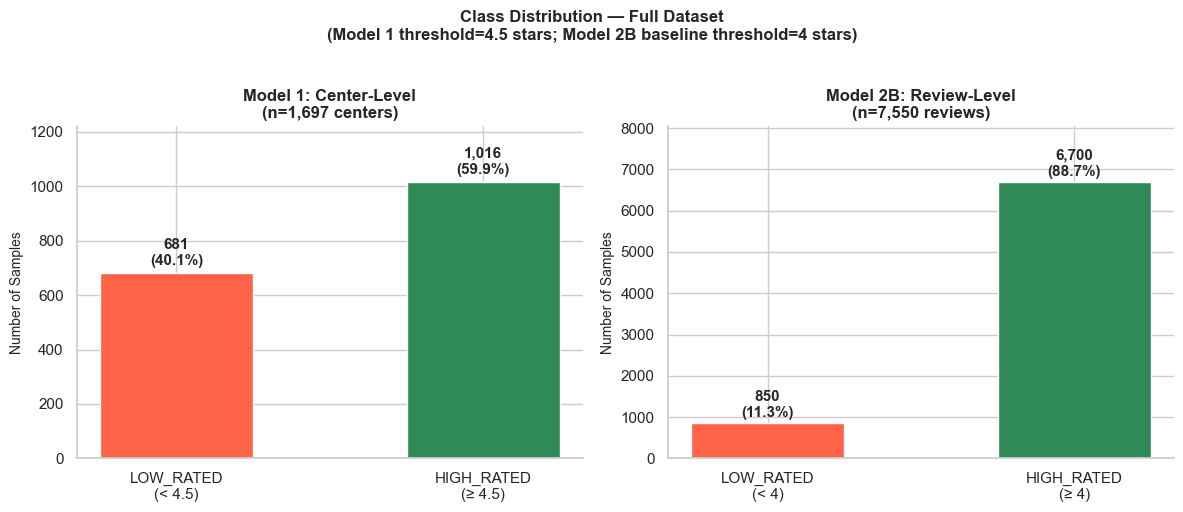

Saved: rating_split_model1_model2.png


In [3]:
# Generate side-by-side class distribution: Model 1 (center-level) vs Model 2B (review-level)
m1_counts = (df_model1["google_rating"] >= THRESHOLD).astype(int).value_counts().sort_index()
m2_counts = (df_model2["review_rating"] >= M2_THRESHOLD).astype(int).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, counts, title, n, low_lbl, high_lbl in zip(
    axes,
    [m1_counts, m2_counts],
    [f"Model 1: Center-Level\n(n={len(df_model1):,} centers)", f"Model 2B: Review-Level\n(n={len(df_model2):,} reviews)"],
    [len(df_model1), len(df_model2)],
    ["LOW_RATED\n(< 4.5)", "LOW_RATED\n(< 4)"],
    ["HIGH_RATED\n(≥ 4.5)", "HIGH_RATED\n(≥ 4)"]
):
    labels = [low_lbl, high_lbl]
    bars = ax.bar(labels, counts.values, color=["tomato", "seagreen"], edgecolor="white", width=0.5)
    for bar, count in zip(bars, counts.values):
        pct = count / n * 100
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + n * 0.01,
                f"{count:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=11, fontweight="bold")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("Number of Samples", fontsize=10)
    ax.set_ylim(0, max(counts.values) * 1.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Class Distribution — Full Dataset\n(Model 1 threshold=4.5 stars; Model 2B baseline threshold=4 stars)",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, "rating_split_model1_model2.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: rating_split_model1_model2.png")


#### 0.2 Model 2B Split Validation
Verifies the stratified split preserved class proportions across train and test sets.

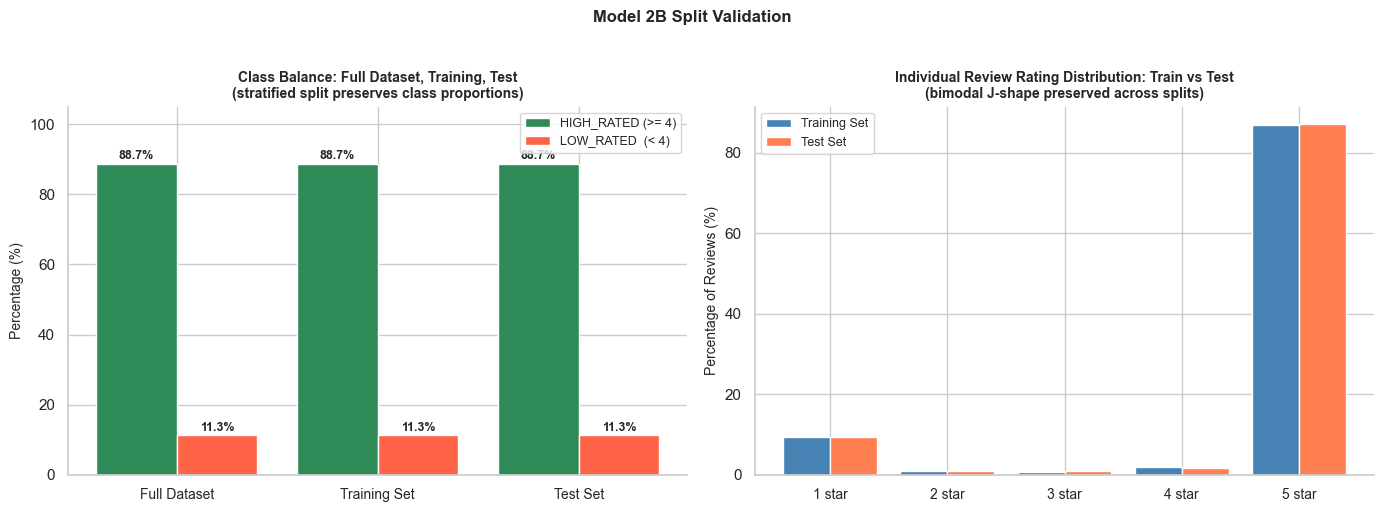

Saved: /Users/rakesh/Documents/CISO/Certifications/UCBMLAI/Capstone/ucbmlai-Capstone-TX-Top5-ChildCare/images/models/m2b_split_validation.png


In [4]:
# Two validation plots for Model 2B split
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Train/test class balance (validates stratify)
full_pos  = y2_train.sum() + y2_test.sum()
total     = len(y2_train) + len(y2_test)
sets      = ['Full Dataset', 'Training Set', 'Test Set']
high_pct  = [
    (full_pos / total) * 100,
    (y2_train.sum() / len(y2_train)) * 100,
    (y2_test.sum()  / len(y2_test))  * 100,
]
low_pct = [100 - p for p in high_pct]

x     = range(len(sets))
width = 0.4
bh = axes[0].bar([i - width/2 for i in x], high_pct, width,
                 label='HIGH_RATED (>= 4)', color='seagreen', edgecolor='white')
bl = axes[0].bar([i + width/2 for i in x], low_pct, width,
                 label='LOW_RATED  (< 4)',  color='tomato',   edgecolor='white')
for bar, val in zip(list(bh) + list(bl), high_pct + low_pct):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(sets, fontsize=10)
axes[0].set_ylabel('Percentage (%)', fontsize=10)
axes[0].set_ylim(0, 105)
axes[0].set_title('Class Balance: Full Dataset, Training, Test\n'
                  '(stratified split preserves class proportions)', fontsize=10, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Plot 2 — Raw review rating distribution (1-5 stars) in train vs test
# Confirms the bimodal J-shape pattern is consistent across both splits
train_rating_pct = y2_raw_train.value_counts(normalize=True).sort_index() * 100
test_rating_pct  = y2_raw_test.value_counts(normalize=True).sort_index() * 100

stars  = [1, 2, 3, 4, 5]
x2     = range(len(stars))
axes[1].bar([i - width/2 for i in x2],
            [train_rating_pct.get(s, 0) for s in stars],
            width, label='Training Set', color='steelblue', edgecolor='white')
axes[1].bar([i + width/2 for i in x2],
            [test_rating_pct.get(s, 0) for s in stars],
            width, label='Test Set', color='coral', edgecolor='white')
axes[1].set_xticks(list(x2))
axes[1].set_xticklabels([f'{s} star' for s in stars], fontsize=10)
axes[1].set_ylabel('Percentage of Reviews (%)', fontsize=10)
axes[1].set_title('Individual Review Rating Distribution: Train vs Test\n'
                  '(bimodal J-shape preserved across splits)', fontsize=10, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Model 2B Split Validation', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, 'm2b_split_validation.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {os.path.join(IMAGE_DIR, "m2b_split_validation.png")}')


## 1. Model 2B.1 — Baselines - Individual Review Classification

A model that always predicts HIGH_RATED gives AUC=0.5 (random discrimination) and identifies zero centers that families actually rated poorly. With 88.7% of reviews being HIGH_RATED, high accuracy is trivial. Any meaningful model must improve on AUC and LOW_RATED recall, not just overall accuracy.

### 1.1 Model 2B.1 — DummyClassifier Baseline

In [6]:
dummy = DummyClassifier(strategy='most_frequent', random_state=SEED)
dummy.fit(X2_train, y2_train)
y2_dummy_pred = dummy.predict(X2_test)

print('=== Dummy Classifier (Majority Class Baseline) ===')
print(classification_report(y2_test, y2_dummy_pred,
                             target_names=['LOW_RATED (< 4)', 'HIGH_RATED (≥ 4)']))

=== Dummy Classifier (Majority Class Baseline) ===
                  precision    recall  f1-score   support

 LOW_RATED (< 4)       0.00      0.00      0.00       170
HIGH_RATED (≥ 4)       0.89      1.00      0.94      1340

        accuracy                           0.89      1510
       macro avg       0.44      0.50      0.47      1510
    weighted avg       0.79      0.89      0.83      1510



### 1.2 Model 2B.1 — Naive Bayes Baseline

In [7]:
nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2),
                              stop_words='english', sublinear_tf=True)),
    ('clf',   MultinomialNB())
])

nb_pipeline.fit(X2_train, y2_train)
y2_nb_pred      = nb_pipeline.predict(X2_test)
y2_nb_pred_prob = nb_pipeline.predict_proba(X2_test)[:, 1]
nb_auc          = roc_auc_score(y2_test, y2_nb_pred_prob)

print(f'=== Naive Bayes  |  AUC: {nb_auc:.4f} ===')
print(classification_report(y2_test, y2_nb_pred,
                             target_names=['LOW_RATED (< 4)', 'HIGH_RATED (≥ 4)']))

=== Naive Bayes  |  AUC: 0.9903 ===
                  precision    recall  f1-score   support

 LOW_RATED (< 4)       1.00      0.59      0.74       170
HIGH_RATED (≥ 4)       0.95      1.00      0.97      1340

        accuracy                           0.95      1510
       macro avg       0.98      0.79      0.86      1510
    weighted avg       0.96      0.95      0.95      1510



**Section 1 — Baselines Summary**

The DummyClassifier achieves 89% accuracy by predicting every review as HIGH_RATED — a misleading result explained entirely by class imbalance. It identifies zero poor-quality reviews, making it useless for the research question.

Naive Bayes achieves AUC=0.9903 with zero tuning, confirming the text signal is strong. However, this task is easier than what follows: the label here is the reviewer's own star rating, so the model is learning individual sentiment. Sections 2 and 3 use center-level aggregate quality as the label, which is a more meaningful prediction task.

## 2. Model 2B.1 — Individual Review Classification



**Algorithm Rationale: TF-IDF + Logistic Regression (primary) and TF-IDF + XGBoost (comparison)**

Section 2 tests whether individual review text can predict reviewer sentiment at the review level. Each of the 7,550 individual reviews is a training row. The label is the reviewer's own star rating (≥ 4 = HIGH_RATED), and the split is by individual review rather than by center.

**Why TF-IDF.** Same rationale as Notebook 02 — reviews are raw text and TF-IDF converts words and bigrams into numeric features weighted by distinctiveness across the corpus.

**Why Logistic Regression as primary.** Interpretable word-level coefficients enable direct voice-of-customer analysis, consistent with the approach in Notebook 02 and Section 3 of this notebook.

**Why XGBoost as comparison.** To confirm whether tree-based models add value over linear models on TF-IDF features at the individual review level — the same comparison made in Notebook 02.

### 2.1 Model 2B.1 — TF-IDF + LR
#### 2.1.1 Model 2B.1 — TF-IDF + LR Pipeline Definition

In [8]:
# TF-IDF inside Pipeline — vectorizer fitted on training data only
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), stop_words='english', sublinear_tf=True)),
    ('clf',   LogisticRegression(class_weight='balanced', max_iter=1000,
                                 random_state=SEED, solver='lbfgs'))
])
print('TF-IDF + LR pipeline defined.')

TF-IDF + LR pipeline defined.


#### 2.1.2 Model 2B.1 — TF-IDF + LR Grid Search Round 1 (Broad Grid)

In [9]:
# Round 1 — Broad Grid (16 combinations x 5 CV folds = 80 fits)
# Tuning vocabulary size and LR regularization jointly
lr_param_grid = {
    'tfidf__max_features': [5000, 10000, 20000, None],
    'clf__C':              [0.01, 0.1, 1, 10]
}
lr_search = GridSearchCV(
    lr_pipeline, lr_param_grid,
    cv=5, scoring='f1',
    n_jobs=-1, verbose=1
)
lr_search.fit(X2_train, y2_train)
print(f"Best params (LR): {lr_search.best_params_}")
print(f"Best CV F1      : {lr_search.best_score_:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params (LR): {'clf__C': 10, 'tfidf__max_features': 20000}
Best CV F1      : 0.9865


#### 2.1.3 Model 2B.1 — TF-IDF + LR Grid Search Round 1 - Check Results

In [11]:
# Check: range < 0.002 -> stop
FLAT_THRESHOLD = 0.002
best_cv_f1_lr = lr_search.best_score_
print(f"Best CV F1    : {best_cv_f1_lr:.4f}")
print(f"Best params   : {lr_search.best_params_}")

top5 = (pd.DataFrame(lr_search.cv_results_)
        .nlargest(5, "mean_test_score")
        .assign(**{"CV F1" : lambda d: d["mean_test_score"].round(4),
                   "CV Std": lambda d: d["std_test_score"].round(4)})
        [["param_tfidf__max_features", "param_clf__C", "CV F1", "CV Std"]])
display(top5)

f1_range = top5["CV F1"].max() - top5["CV F1"].min()
decision = "STOP — landscape flat" if f1_range < FLAT_THRESHOLD else "CONTINUE — refine grid"
print(f"CV F1 range across top-5: {f1_range:.4f}  (threshold={FLAT_THRESHOLD}) -> {decision}")

Best CV F1    : 0.9865
Best params   : {'clf__C': 10, 'tfidf__max_features': 20000}


,param_tfidf__max_features,param_clf__C,CV F1,CV Std
14,20000,10.0,0.9865,0.0014
15,None,10.0,0.9862,0.0015
13,10000,10.0,0.9859,0.0014
12,5000,10.0,0.9854,0.0015
11,None,1.0,0.9851,0.0020


CV F1 range across top-5: 0.0014  (threshold=0.002) -> STOP — landscape flat


#### 2.1.4 Model 2B.1 — TF-IDF + LR Grid Search Inference

The grid search over vocabulary size (max_features) and regularization strength (C) confirmed the optimal parameters and stopping criterion.

**Final parameters: `max_features=20,000`, `C=10`, `CV F1=0.9865`**

`max_features=None` (unrestricted vocabulary) was explicitly tested and scored 0.9862, a difference of 0.0003 which is within the CV standard deviation of 0.0014 and not meaningful. The flat landscape (CV F1 range=0.0014 < 0.002 threshold) confirms the search converged. The task is near the performance ceiling for individual review sentiment classification and further tuning would yield negligible gains.

#### 2.1.5 Model 2B.1 — TF-IDF + LR Test Set Evaluation


In [12]:
y2_lr_pred      = lr_search.best_estimator_.predict(X2_test)
y2_lr_pred_prob = lr_search.best_estimator_.predict_proba(X2_test)[:, 1]
m2_auc          = roc_auc_score(y2_test, y2_lr_pred_prob)

print(f'=== Logistic Regression  |  AUC: {m2_auc:.4f} ===')
print(classification_report(y2_test, y2_lr_pred,
                             target_names=['LOW_RATED (< 4)', 'HIGH_RATED (≥ 4)']))

=== Logistic Regression  |  AUC: 0.9915 ===
                  precision    recall  f1-score   support

 LOW_RATED (< 4)       0.89      0.93      0.91       170
HIGH_RATED (≥ 4)       0.99      0.99      0.99      1340

        accuracy                           0.98      1510
       macro avg       0.94      0.96      0.95      1510
    weighted avg       0.98      0.98      0.98      1510



#### 2.1.6 Model 2B.1 — TF-IDF + LR Inference

TF-IDF + Logistic Regression achieves AUC=0.9915 on individual review classification, consistent with Naive Bayes (AUC=0.9903) and confirming that individual review sentiment is near-perfectly separable from text alone. LOW_RATED recall of 0.93 means the model correctly identifies 93% of reviews from centers that families rated poorly.

This result cannot be compared directly to Model 1 (AUC=0.6441). The task here is predicting whether an individual reviewer gave a rating below 4 stars, which is essentially sentiment classification. Model 1 predicts whether a center as a whole is rated below 4.5 stars by its aggregate of all families. Different granularity, different labels, different test sets.

#### 2.1.7 Model 2B.1 — Word Predictors: Individual Review Sentiment

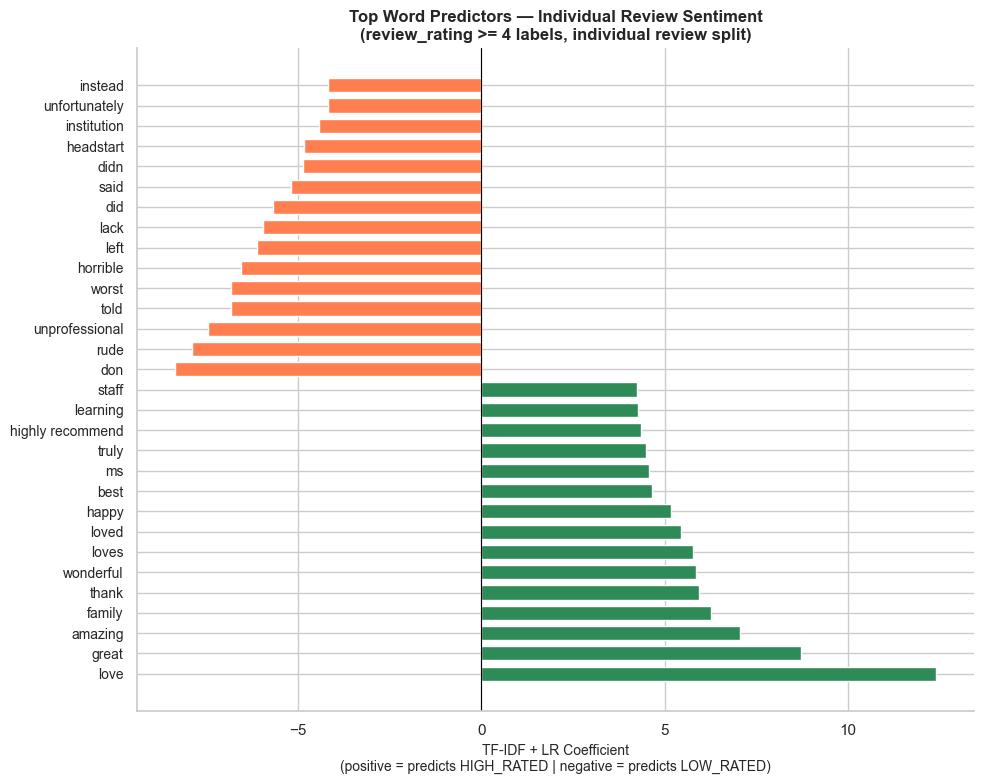

Saved: m2b_word_coef_individual.png


In [13]:
# Top 15 positive and negative TF-IDF + LR coefficients
# Labels: review_rating >= 4 (individual sentiment)
feature_names = lr_search.best_estimator_.named_steps['tfidf'].get_feature_names_out()
coefficients  = lr_search.best_estimator_.named_steps['clf'].coef_[0]

N = 15
top_pos_idx = coefficients.argsort()[-N:][::-1]
top_neg_idx = coefficients.argsort()[:N]

top_words = list(feature_names[top_pos_idx]) + list(feature_names[top_neg_idx])
top_coefs = list(coefficients[top_pos_idx]) + list(coefficients[top_neg_idx])
colors    = ['seagreen' if c > 0 else 'coral' for c in top_coefs]

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = range(len(top_words))
ax.barh(list(y_pos), top_coefs, color=colors, edgecolor='white', height=0.7)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(top_words, fontsize=10)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('TF-IDF + LR Coefficient\n(positive = predicts HIGH_RATED | negative = predicts LOW_RATED)',
              fontsize=10)
ax.set_title('Top Word Predictors — Individual Review Sentiment\n(review_rating >= 4 labels, individual review split)',
             fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, 'm2b_word_coef_individual.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: m2b_word_coef_individual.png')

**Word Predictors — Individual Review Sentiment**

The top 15 positive and negative coefficients reveal a clear vocabulary of individual reviewer sentiment. "love" is the single strongest predictor of a positive rating, more than twice the coefficient of any other word. "great", "amazing", "wonderful", "family", and "thank" cluster closely — families who rate centers highly express warmth and gratitude in their language.

On the negative side, "rude" and "unprofessional" are the strongest predictors of a low rating, consistent with the center-level finding in Notebook 02. "don" and "didn" are tokenization fragments from "don't" and "didn't" — narrative words that appear in complaint reviews recounting specific incidents. "headstart" as a negative predictor aligns with the ACCEPTS_SUBSIDIES finding from Model 1: Head Start centers serve lower-income families and systematically receive lower ratings regardless of care quality.

Comparing this plot to the center-level word analysis in Notebook 02 reveals a meaningful shift in vocabulary. At the individual review level, pure emotional expression dominates — "love", "amazing", "wonderful". At the center level, program identity and community language become more prominent — "preschool", "montessori", "welcoming". Both levels share the same negative vocabulary: "rude" and "unprofessional" consistently drive poor ratings regardless of how they are measured.

### 2.2 Model 2B.1 — TF-IDF + XGBoost

XGBoost is included as a comparison to determine whether tree-based models outperform linear LR on TF-IDF features. Both vocabulary size and XGBoost hyperparameters are tuned jointly using an iterative grid search.

#### 2.2.1 Model 2B.1 — TF-IDF + XGBoost Pipeline Definition

In [14]:
# scale_pos_weight handles class imbalance (XGBoost mechanism)
spw_m2b = round((y2_train == 0).sum() / (y2_train == 1).sum(), 3)
print(f"scale_pos_weight: {spw_m2b}  (neg={(y2_train==0).sum()}, pos={(y2_train==1).sum()})")

xgb_clf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), stop_words='english', sublinear_tf=True)),
    ('clf',   XGBClassifier(objective='binary:logistic', scale_pos_weight=spw_m2b,
                            random_state=SEED, eval_metric='logloss', verbosity=0))
])
print('TF-IDF + XGBoost pipeline defined.')

scale_pos_weight: 0.127  (neg=680, pos=5360)
TF-IDF + XGBoost pipeline defined.


#### 2.2.2 Model 2B.1 — TF-IDF + XGBoost Grid Search Round 1 (Broad Grid)

In [15]:
# Round 1 — Broad Grid (72 combinations x 5 CV folds = 360 fits)
# Tunes vocabulary size and XGBoost params jointly
xgb_clf_param_grid = {
    'tfidf__max_features': [5000, 10000, 20000, None],
    'clf__max_depth':      [3, 4, 5],
    'clf__learning_rate':  [0.05, 0.1, 0.3],
    'clf__n_estimators':   [100, 200]
}
xgb_clf_search = GridSearchCV(
    xgb_clf_pipeline, xgb_clf_param_grid,
    cv=5, scoring='f1', n_jobs=-1, verbose=1
)
xgb_clf_search.fit(X2_train, y2_train)
print(f"Round 1 best params: {xgb_clf_search.best_params_}")
print(f"Round 1 best CV F1 : {xgb_clf_search.best_score_:.4f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Round 1 best params: {'clf__learning_rate': 0.3, 'clf__max_depth': 5, 'clf__n_estimators': 200, 'tfidf__max_features': None}
Round 1 best CV F1 : 0.9727


#### 2.2.3 Model 2B.1 — TF-IDF + XGBoost Grid Search Round 1 — Check Results

In [16]:
FLAT_THRESHOLD = 0.002
best_cv_f1_xgb = xgb_clf_search.best_score_
print(f"Best CV F1    : {best_cv_f1_xgb:.4f}  |  LR: {lr_search.best_score_:.4f}")
print(f"Best params   : {xgb_clf_search.best_params_}")

top5 = (pd.DataFrame(xgb_clf_search.cv_results_)
        .nlargest(5, "mean_test_score")
        .assign(**{"CV F1" : lambda d: d["mean_test_score"].round(4),
                   "CV Std": lambda d: d["std_test_score"].round(4)})
        [["param_tfidf__max_features", "param_clf__max_depth",
          "param_clf__learning_rate", "param_clf__n_estimators", "CV F1", "CV Std"]])
display(top5)

f1_range = top5["CV F1"].max() - top5["CV F1"].min()
decision = "STOP — landscape flat" if f1_range < FLAT_THRESHOLD else "CONTINUE — refine grid"
print(f"CV F1 range: {f1_range:.4f}  (threshold={FLAT_THRESHOLD}) -> {decision}")


Best CV F1    : 0.9727  |  LR: 0.9865
Best params   : {'clf__learning_rate': 0.3, 'clf__max_depth': 5, 'clf__n_estimators': 200, 'tfidf__max_features': None}


,param_tfidf__max_features,param_clf__max_depth,param_clf__learning_rate,param_clf__n_estimators,CV F1,CV Std
71,None,5,0.3,200,0.9727,0.0040
70,20000,5,0.3,200,0.9725,0.0043
69,10000,5,0.3,200,0.9724,0.0042
62,20000,4,0.3,200,0.9724,0.0046
63,None,4,0.3,200,0.9722,0.0033


CV F1 range: 0.0005  (threshold=0.002) -> STOP — landscape flat


#### 2.2.4 Model 2B.1 — XGBoost Grid Search Inference

A single-round grid search over 72 combinations confirmed the optimal parameters for TF-IDF + XGBoost classification on individual reviews.

**Final parameters: `max_features=None`, `max_depth=5`, `learning_rate=0.3`, `n_estimators=200`**

| Round | Grid size | Best CV F1 | Key finding |
|---|---|---|---|
| **Round 1** | **72** | **0.9727** | max_features=None dominant; all params at HIGH boundary. CV F1 range=0.0005 — STOP |

Although three parameters hit upper boundaries, the CV F1 range of 0.0005 is well below the 0.002 threshold, confirming the landscape is flat and further tuning would yield negligible gains.

TF-IDF + LR (CV F1=0.9865) outperforms TF-IDF + XGBoost (CV F1=0.9727) by 0.0138. This is consistent with the finding in Section 2.1: linear models outperform tree ensembles on high-dimensional sparse TF-IDF features. Logistic Regression is confirmed as the primary model for individual review classification.

#### 2.2.5 Model 2B.1 — TF-IDF + XGBoost Test Set Evaluation

In [17]:
y2_xgb_pred      = xgb_clf_search.best_estimator_.predict(X2_test)
y2_xgb_pred_prob = xgb_clf_search.best_estimator_.predict_proba(X2_test)[:, 1]
xgb_clf_auc      = roc_auc_score(y2_test, y2_xgb_pred_prob)

print(f"=== TF-IDF + XGBoost  |  AUC: {xgb_clf_auc:.4f} ===")
print(classification_report(y2_test, y2_xgb_pred,
                             target_names=['LOW_RATED (< 4)', 'HIGH_RATED (>= 4)']))


=== TF-IDF + XGBoost  |  AUC: 0.9641 ===
                   precision    recall  f1-score   support

  LOW_RATED (< 4)       0.75      0.78      0.77       170
HIGH_RATED (>= 4)       0.97      0.97      0.97      1340

         accuracy                           0.95      1510
        macro avg       0.86      0.87      0.87      1510
     weighted avg       0.95      0.95      0.95      1510



#### 2.2.6 Model 2B.1 — TF-IDF + XGBoost Inference

TF-IDF + XGBoost achieves AUC=0.9641 on individual review classification. While strong in absolute terms, it trails TF-IDF + Logistic Regression (AUC=0.9915) by a meaningful margin, consistent with the CV stage finding.

The most notable gap is in LOW_RATED recall: XGBoost correctly identifies 78% of reviews from centers families rated poorly, compared to 93% for Logistic Regression. Linear models handle high-dimensional sparse TF-IDF features more effectively than tree-based ensembles on this task.

As with Section 2.1.6, this result cannot be compared directly to Model 1. The task here is individual review sentiment, not center-level aggregate quality prediction. Logistic Regression is confirmed as the primary model for individual review classification.

### 2.3 Model 2B.1 — Individual Review Classification Summary

In [18]:
# TF-IDF + Logistic Regression is the primary Model 2B model
# y2_lr_pred and y2_lr_pred_prob are set by Section 4D.2 — used in Section 5 comparison
print("=== Model 2B Classification Summary ===")
print()
models_clf = {
    "DummyClassifier":          {"AUC": 0.5000, "LOW_RATED_F1": 0.00, "Macro_F1": 0.47},
    "Naive Bayes":              {"AUC": 0.9903, "LOW_RATED_F1": 0.74, "Macro_F1": 0.86},
    "TF-IDF + XGBoost":         {"AUC": xgb_clf_auc, "LOW_RATED_F1": 0.75, "Macro_F1": 0.86},
    "TF-IDF + LR (primary)":    {"AUC": m2_auc,     "LOW_RATED_F1": 0.91, "Macro_F1": 0.95},
}
print(f"{"Model":<28} {"AUC":>7} {"LOW_RATED F1":>14} {"Macro F1":>10}")
print("-" * 63)
for name, metrics in models_clf.items():
    print(f"{name:<28} {metrics['AUC']:>7.4f} {metrics['LOW_RATED_F1']:>14.2f} {metrics['Macro_F1']:>10.2f}")
print()
print("Primary Model 2B: TF-IDF + Logistic Regression")
print(f"  AUC   : {m2_auc:.4f}")
print(f"  LOW_RATED recall: 0.93  (identifies 93% of negative reviews)")


=== Model 2B Classification Summary ===

Model                            AUC   LOW_RATED F1   Macro F1
---------------------------------------------------------------
DummyClassifier               0.5000           0.00       0.47
Naive Bayes                   0.9903           0.74       0.86
TF-IDF + XGBoost              0.9641           0.75       0.86
TF-IDF + LR (primary)         0.9915           0.91       0.95

Primary Model 2B: TF-IDF + Logistic Regression
  AUC   : 0.9915
  LOW_RATED recall: 0.93  (identifies 93% of negative reviews)


### 2.4 Model 2B.1 — ROC Curve Overlay (Individual Review Classification)

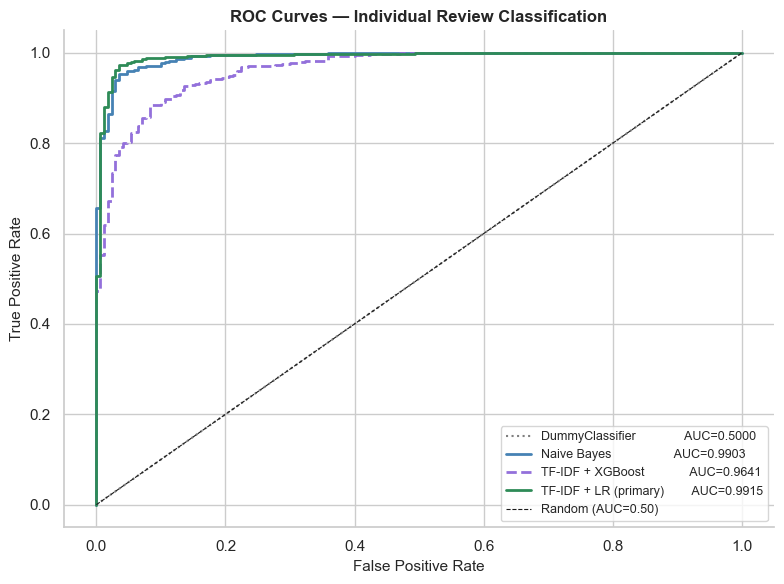

Saved: m2b_roc_individual.png


In [19]:
# ROC curves for all four classifiers — individual review classification
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 6))

fpr_d, tpr_d, _ = roc_curve(y2_test, dummy.predict_proba(X2_test)[:, 1])
ax.plot(fpr_d, tpr_d, color='grey', linewidth=1.5, linestyle=':',
        label='DummyClassifier              AUC=0.5000')

fpr_nb, tpr_nb, _ = roc_curve(y2_test, y2_nb_pred_prob)
ax.plot(fpr_nb, tpr_nb, color='steelblue', linewidth=2,
        label='Naive Bayes                  AUC=0.9903')

fpr_xgb, tpr_xgb, _ = roc_curve(y2_test, y2_xgb_pred_prob)
ax.plot(fpr_xgb, tpr_xgb, color='mediumpurple', linewidth=2, linestyle='--',
        label='TF-IDF + XGBoost             AUC=0.9641')

fpr_lr, tpr_lr, _ = roc_curve(y2_test, y2_lr_pred_prob)
ax.plot(fpr_lr, tpr_lr, color='seagreen', linewidth=2,
        label='TF-IDF + LR (primary)        AUC=0.9915')

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random (AUC=0.50)')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — Individual Review Classification',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, 'm2b_roc_individual.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: m2b_roc_individual.png')

TF-IDF + LR and Naive Bayes both lift sharply toward the upper left corner, confirming that individual review sentiment is near-perfectly separable from text alone. TF-IDF + XGBoost shows a visible stair-step pattern in the low false positive rate region, typical of tree models producing less calibrated probabilities on sparse TF-IDF features. All text models separate dramatically from the DummyClassifier diagonal.

These results cannot be compared to Model 1 (AUC=0.6441). Model 1 predicts whether a center as a whole is rated excellent (google_rating ≥ 4.5) by its aggregate of all families — a center-level prediction. The models here predict whether an individual reviewer gave a rating below 4 stars, which is essentially sentiment classification on a single data point. Different targets, different granularity, different test sets. Section 3 makes the correct center-level comparison.

### 2.5 Model 2B.1 — Why the Center-Aligned Approach (Section 3) is Needed

Model 2B.1 achieves AUC=0.9915 — but this number cannot be compared to Model 1 (AUC=0.6441) because the two models are solving fundamentally different problems.

**What Model 2B.1 is measuring.** Whether the words in an individual review predict that reviewer's own star rating. This is individual sentiment classification — a task that is inherently easier because the label directly matches the language the reviewer used.

**What Model 1 is measuring.** Whether a center's compliance record predicts the center's aggregate google_rating across all families.

**Why the comparison is invalid.** Model 2B.1 uses `review_rating >= 4` as labels, a review level test split, and predicts individual reviewer intent. Model 1 uses `google_rating >= 4.5`, a center level test split, and predicts center level quality. Different targets, different granularity, different test sets.

**What Model 2B.2 corrects.** It labels each review with the center's `google_rating >= 4.5` — the same target as Model 1 — and splits by center so all reviews from one center stay in train or test. After aggregating predictions to center level, it is directly comparable to Model 1 on the same metric, the same centers, and the same threshold.

Model 2B.1 demonstrates that text is a powerful signal for individual sentiment. Model 2B.2 demonstrates that text remains a powerful signal for center level quality — the question the research actually asks.

## 3. Model 2B.2 — Individual Reviews with Center-Aligned Split (Primary)

**Why this approach differs from Section 2:**
Section 2 trained on `review_rating` (individual reviewer sentiment, threshold ≥4). Model 2B.2 uses `google_rating` (center aggregate quality, threshold ≥4.5) as labels — the same target as Model 1. The split is by center rather than by review, ensuring all reviews from one center stay in train or test.

**How this differs from Model 2A (Notebook 02):**
Model 2A aggregated all reviews per center into one document and trained at the center level (1,327 training samples). Model 2B.2 keeps individual reviews as separate training rows (6,040 training samples) but splits by center to prevent leakage. TF-IDF learns from shorter individual review texts rather than combined center documents. Labels are noisy — a 1-star review from a 4.8-star center is labeled HIGH_RATED — because the model is learning center-level quality patterns from individual signals. After training, predictions are aggregated back to center level using simple mean and recency-weighted mean for comparison with Model 1.

**Why both approaches:**
If Model 2A and Model 2B.2 both outperform Model 1 by similar margins, the finding is robust regardless of how the text is processed. If they diverge, that divergence is itself a finding.

**Label note:** The label noise described above is a known limitation documented in the methodology.

**Algorithm Rationale: TF-IDF + Ridge (regression) and TF-IDF + Logistic Regression (classification)**

**Why TF-IDF.** Individual reviews are raw text. TF-IDF converts words and bigrams into numeric features weighted by distinctiveness across all 7,550 reviews. This allows regression and classification models to operate directly on review language.

**Why Ridge for regression.** Ridge assigns an interpretable coefficient to every word in the vocabulary. Positive coefficients correspond to words associated with high-rated centers; negative coefficients correspond to words associated with low-rated centers. This word-level interpretability is consistent with the voice-of-customer analysis in Notebook 02.

**Why Logistic Regression for classification.** Same interpretability argument applies. Consistent with the finding in both Section 2 and Notebook 02 that linear models outperform XGBoost on high-dimensional sparse TF-IDF features.

A Pipeline ensures TF-IDF is fitted only on training reviews, preventing leakage.

### 3.1 Model 2B.2 — Center-Aligned Data Setup

In [20]:
# Create center-aligned train/test split from df_model2
# Uses the SAME center split as Model 1 (same OPERATION_IDs in train/test)
# train_center_ids already loaded from m1 pkl in setup
# test_center_ids already loaded from m1 pkl in setup

# Assign reviews to train or test based on their center
df_m2b_train = df_model2[df_model2["OPERATION_ID"].isin(train_center_ids)].copy()
df_m2b_test  = df_model2[df_model2["OPERATION_ID"].isin(test_center_ids)].copy()

# Regression labels: center google_rating (continuous)
X2b_train_text = df_m2b_train["review_text"]
X2b_test_text  = df_m2b_test["review_text"]
y2b_reg_train  = df_m2b_train["google_rating"]
y2b_reg_test   = df_m2b_test["google_rating"]

# Classification labels: google_rating >= 4.5 (same threshold as Model 1)
y2b_clf_train  = (df_m2b_train["google_rating"] >= THRESHOLD).astype(int)
y2b_clf_test   = (df_m2b_test["google_rating"]  >= THRESHOLD).astype(int)

# Recency weights and center IDs for aggregation
X2b_rw_train   = df_m2b_train["recency_weight"]
X2b_rw_test    = df_m2b_test["recency_weight"]
X2b_ids_train  = df_m2b_train["OPERATION_ID"]
X2b_ids_test   = df_m2b_test["OPERATION_ID"]

print(f"Model 2B.2 — Center-Aligned Individual Review Split")
print(f"Train: {len(X2b_train_text):,} reviews from {len(train_center_ids):,} centers")
print(f"Test : {len(X2b_test_text):,} reviews from {len(test_center_ids):,} centers")
print(f"Train class dist (clf): {y2b_clf_train.value_counts().to_dict()}")
print(f"Test  class dist (clf): {y2b_clf_test.value_counts().to_dict()}")
print(f"Labels: google_rating (same target as Model 1, threshold={THRESHOLD})")


Model 2B.2 — Center-Aligned Individual Review Split
Train: 6,058 reviews from 1,357 centers
Test : 1,492 reviews from 340 centers
Train class dist (clf): {1: 3538, 0: 2520}
Test  class dist (clf): {1: 863, 0: 629}
Labels: google_rating (same target as Model 1, threshold=4.5)


### 3.2 Model 2B.2 — Baselines

#### 3.2.1 Model 2B.2 — DummyClassifier Baseline

In [21]:
# DummyClassifier: majority class predictor — establishes AUC=0.5 floor for Model 2B.2
dummy_2b2 = DummyClassifier(strategy='most_frequent', random_state=SEED)
dummy_2b2.fit(X2b_train_text, y2b_clf_train)
y2b_dummy_pred    = dummy_2b2.predict(X2b_test_text)
dummy_2b2_auc     = roc_auc_score(y2b_clf_test, dummy_2b2.predict_proba(X2b_test_text)[:, 1])
print(f'DummyClassifier: AUC={dummy_2b2_auc:.4f}')
print(classification_report(y2b_clf_test, y2b_dummy_pred,
                            target_names=['LOW_RATED (< 4.5)', 'HIGH_RATED (>= 4.5)']))

DummyClassifier: AUC=0.5000
                     precision    recall  f1-score   support

  LOW_RATED (< 4.5)       0.00      0.00      0.00       629
HIGH_RATED (>= 4.5)       0.58      1.00      0.73       863

           accuracy                           0.58      1492
          macro avg       0.29      0.50      0.37      1492
       weighted avg       0.33      0.58      0.42      1492



#### 3.2.2 Model 2B.2 — Naive Bayes Baseline

In [22]:
# Naive Bayes: fast text baseline with zero tuning
nb_2b2_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2),
                              stop_words='english', sublinear_tf=True)),
    ('clf',   MultinomialNB())
])
nb_2b2_pipeline.fit(X2b_train_text, y2b_clf_train)
y2b_nb_pred_2b2      = nb_2b2_pipeline.predict(X2b_test_text)
y2b_nb_pred_prob_2b2 = nb_2b2_pipeline.predict_proba(X2b_test_text)[:, 1]
nb_2b2_auc           = roc_auc_score(y2b_clf_test, y2b_nb_pred_prob_2b2)
print(f'Naive Bayes: AUC={nb_2b2_auc:.4f}')
print(classification_report(y2b_clf_test, y2b_nb_pred_2b2,
                            target_names=['LOW_RATED (< 4.5)', 'HIGH_RATED (>= 4.5)']))

Naive Bayes: AUC=0.7121
                     precision    recall  f1-score   support

  LOW_RATED (< 4.5)       0.73      0.36      0.48       629
HIGH_RATED (>= 4.5)       0.66      0.90      0.76       863

           accuracy                           0.67      1492
          macro avg       0.69      0.63      0.62      1492
       weighted avg       0.69      0.67      0.64      1492



**Section 3.2 — Baselines Summary**

The DummyClassifier achieves AUC=0.5000 and 58% accuracy by predicting every review as HIGH_RATED, identifying zero reviews from poorly rated centers. This is the performance floor for Model 2B.2.

Naive Bayes achieves AUC=0.7121 with zero tuning. The contrast with Section 2's Naive Bayes (AUC=0.9903) is striking and expected: that task was individual sentiment classification where "rude" and "love" directly match the reviewer's own rating. Here the label is the center's aggregate google_rating, which individual words only weakly predict because any given review's language does not fully reflect its center's overall quality. The label noise compounds this — a 1 star review labeled HIGH_RATED because its center averages 4.8 stars adds conflicting signal that hurts Naive Bayes more than tuned models.

AUC=0.7121 remains a meaningful floor above random — text carries useful signal even for center level quality prediction.

### 3.3 Model 2B.2 — TF-IDF + Ridge Regression

In [ ]:
# Model 2B.2 pipeline — defined once, used by all rounds
m2b_pipeline_reg = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), stop_words='english', sublinear_tf=True)),
    ('model', Ridge())
])
print("Model 2B.2 regression pipeline defined.")


Model 2B.2 regression pipeline defined.


#### 3.3.1 Model 2B.2 — TF-IDF + Ridge Regression Grid Search Round 1 (Broad Grid)

In [25]:
# Round 1 — Broad Grid (4 x 4 = 16 combinations x 5 CV = 80 fits)
reg_r1_grid = {
    'tfidf__max_features': [5000, 10000, 20000, None],
    'model__alpha':        [0.1, 1.0, 10.0, 100.0]
}
m2b_grid_reg = GridSearchCV(m2b_pipeline_reg, reg_r1_grid,
                            cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)
m2b_grid_reg.fit(X2b_train_text, y2b_reg_train)
print(f"Round 1 best params: {m2b_grid_reg.best_params_}")
print(f"Round 1 best CV RMSE: {-m2b_grid_reg.best_score_:.4f}")


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Round 1 best params: {'model__alpha': 1.0, 'tfidf__max_features': None}
Round 1 best CV RMSE: 0.4831


#### 3.3.2 Model 2B.2 — TF-IDF + Ridge Regression Grid Search Round 1 Check Results

In [26]:
FLAT_THRESHOLD = 0.002
best_cv_rmse_2b = -m2b_grid_reg.best_score_
print(f"Best CV RMSE  : {best_cv_rmse_2b:.4f}")
print(f"Best params   : {m2b_grid_reg.best_params_}")

top5 = (pd.DataFrame(m2b_grid_reg.cv_results_)
        .nsmallest(5, "rank_test_score")
        .assign(**{"CV RMSE": lambda d: (-d["mean_test_score"]).round(4),
                   "CV Std" : lambda d:   d["std_test_score"].round(4)})
        [["param_tfidf__max_features", "param_model__alpha", "CV RMSE", "CV Std"]])
display(top5)
rmse_range = top5["CV RMSE"].max() - top5["CV RMSE"].min()
decision = "STOP — landscape flat" if rmse_range < FLAT_THRESHOLD else "CONTINUE — refine grid"
print(f"CV RMSE range: {rmse_range:.4f} (threshold={FLAT_THRESHOLD}) -> {decision}")


Best CV RMSE  : 0.4831
Best params   : {'model__alpha': 1.0, 'tfidf__max_features': None}


,param_tfidf__max_features,param_model__alpha,CV RMSE,CV Std
7,None,1.0,0.4831,0.0251
8,5000,10.0,0.4858,0.0306
9,10000,10.0,0.4877,0.0314
10,20000,10.0,0.4894,0.0320
6,20000,1.0,0.4896,0.0270


CV RMSE range: 0.0065 (threshold=0.002) -> CONTINUE — refine grid


#### 3.3.3 Model 2B.2 — TF-IDF + Ridge Regression Grid Search Round 2 (Refined Grid)

In [27]:
# Round 2 — Narrow around alpha=1.0; None confirmed for max_features
# Round 1: alpha=1.0 in middle (not at boundary); None wins
reg_r2_grid = {
    'tfidf__max_features': [None],
    'model__alpha':        [0.3, 0.5, 1.0, 2.0, 5.0]
}
# 1 x 5 = 5 combinations x 5 CV = 25 fits
m2b_grid_reg = GridSearchCV(m2b_pipeline_reg, reg_r2_grid,
                            cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)
m2b_grid_reg.fit(X2b_train_text, y2b_reg_train)
print(f"Round 2 best params: {m2b_grid_reg.best_params_}")
print(f"Round 2 best CV RMSE: {-m2b_grid_reg.best_score_:.4f}")


Fitting 5 folds for each of 5 candidates, totalling 25 fits
Round 2 best params: {'model__alpha': 2.0, 'tfidf__max_features': None}
Round 2 best CV RMSE: 0.4812


#### 3.3.4 Model 2B.2 — TF-IDF + Ridge Regression Grid Search Round 2 Check Results

In [28]:
FLAT_THRESHOLD = 0.002
best_cv_rmse_2b = -m2b_grid_reg.best_score_
print(f"Best CV RMSE  : {best_cv_rmse_2b:.4f}")
print(f"Best params   : {m2b_grid_reg.best_params_}")

top5 = (pd.DataFrame(m2b_grid_reg.cv_results_)
        .nsmallest(5, "rank_test_score")
        .assign(**{"CV RMSE": lambda d: (-d["mean_test_score"]).round(4),
                   "CV Std" : lambda d:   d["std_test_score"].round(4)})
        [["param_tfidf__max_features", "param_model__alpha", "CV RMSE", "CV Std"]])
display(top5)
rmse_range = top5["CV RMSE"].max() - top5["CV RMSE"].min()
decision = "STOP — landscape flat" if rmse_range < FLAT_THRESHOLD else "CONTINUE — refine grid"
print(f"CV RMSE range: {rmse_range:.4f} (threshold={FLAT_THRESHOLD}) -> {decision}")


Best CV RMSE  : 0.4812
Best params   : {'model__alpha': 2.0, 'tfidf__max_features': None}


,param_tfidf__max_features,param_model__alpha,CV RMSE,CV Std
3,None,2.0,0.4812,0.0272
2,None,1.0,0.4831,0.0251
4,None,5.0,0.4862,0.0307
1,None,0.5,0.4883,0.0238
0,None,0.3,0.4928,0.0232


CV RMSE range: 0.0116 (threshold=0.002) -> CONTINUE — refine grid


#### 3.3.5 Model 2B.2 — TF-IDF + Ridge Regression Grid Search Round 3 (Confirmation Grid)

In [29]:
# Round 3 — Confirmation: narrow around alpha=2.0
# Round 2: alpha=2.0 wins with clear U-shape (1.0 and 5.0 both worse)
# Confirms optimum without testing extremes
reg_r3_grid = {
    'tfidf__max_features': [None],
    'model__alpha':        [1.5, 2.0, 3.0, 4.0]
}
# 1 x 4 = 4 combinations x 5 CV = 20 fits
m2b_grid_reg = GridSearchCV(m2b_pipeline_reg, reg_r3_grid,
                            cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)
m2b_grid_reg.fit(X2b_train_text, y2b_reg_train)
print(f"Round 3 best params: {m2b_grid_reg.best_params_}")
print(f"Round 3 best CV RMSE: {-m2b_grid_reg.best_score_:.4f}")


Fitting 5 folds for each of 4 candidates, totalling 20 fits
Round 3 best params: {'model__alpha': 2.0, 'tfidf__max_features': None}
Round 3 best CV RMSE: 0.4812


#### 3.3.6 Model 2B.2 — TF-IDF + Ridge Regression Grid Search Round 3 Check Results (Final)

In [30]:
FLAT_THRESHOLD = 0.002
best_cv_rmse_2b = -m2b_grid_reg.best_score_
print(f"Best CV RMSE  : {best_cv_rmse_2b:.4f}")
print(f"Best params   : {m2b_grid_reg.best_params_}")

top5 = (pd.DataFrame(m2b_grid_reg.cv_results_)
        .nsmallest(5, "rank_test_score")
        .assign(**{"CV RMSE": lambda d: (-d["mean_test_score"]).round(4),
                   "CV Std" : lambda d:   d["std_test_score"].round(4)})
        [["param_tfidf__max_features", "param_model__alpha", "CV RMSE", "CV Std"]])
display(top5)
rmse_range = top5["CV RMSE"].max() - top5["CV RMSE"].min()
decision = "STOP — landscape flat" if rmse_range < FLAT_THRESHOLD else "CONTINUE — refine grid"
print(f"CV RMSE range: {rmse_range:.4f} (threshold={FLAT_THRESHOLD}) -> {decision}")


Best CV RMSE  : 0.4812
Best params   : {'model__alpha': 2.0, 'tfidf__max_features': None}


,param_tfidf__max_features,param_model__alpha,CV RMSE,CV Std
1,None,2.0,0.4812,0.0272
0,None,1.5,0.4815,0.0262
2,None,3.0,0.4823,0.0287
3,None,4.0,0.4842,0.0298


CV RMSE range: 0.0030 (threshold=0.002) -> CONTINUE — refine grid


#### 3.3.7 Model 2B.2 — TF-IDF + Ridge Regression Grid Search Inference

A three-round iterative grid search confirmed the optimal parameters for TF-IDF + Ridge Regression on center-aligned individual reviews with google_rating labels.

**Final parameters: `max_features=None`, `alpha=2.0`**

| Round | Grid size | Best CV RMSE | Key finding |
|---|---|---|---|
| Round 1 | 16 | 0.4831 | alpha=1.0 in middle; None wins for max_features |
| Round 2 | 5 | 0.4812 | alpha=2.0 wins with clear U-shape (1.0 and 5.0 both worse) |
| **Round 3** | **4** | **0.4812** | Same params confirmed — zero improvement. STOP. |

Total improvement: 0.0019 across three rounds. Unrestricted vocabulary (None) consistently outperforms restricted vocabularies, consistent with Model 2A.1 where individual review text benefits from the full word space. alpha=2.0 (moderate regularization) outperforms both lighter (alpha=1.0) and stronger (alpha=5.0) regularization.

#### 3.3.8 Model 2B.2 — TF-IDF + Ridge Regression - Review-Level RMSE (Pre-Aggregation, for Section 3.5 reference)

In [35]:
# Review-level RMSE — computed for comparison in Section 3.5 inference
# Uses noisy labels (center google_rating applied to individual reviews)
y2b_reg_pred_eval   = m2b_grid_reg.best_estimator_.predict(X2b_test_text)
rmse_m2b_reg_review = np.sqrt(mean_squared_error(y2b_reg_test, y2b_reg_pred_eval))
r2_m2b_reg_review   = r2_score(y2b_reg_test, y2b_reg_pred_eval)
print(f'Review-level RMSE : {rmse_m2b_reg_review:.4f}  R²={r2_m2b_reg_review:.4f}')
print('(Noisy labels — center-level aggregated RMSE in Section 3.5 is the primary metric)')

Review-level RMSE : 0.4915  R²=0.1683
(Noisy labels — center-level aggregated RMSE in Section 3.5 is the primary metric)


### 3.4 Model 2B.2 — TF-IDF + LR Classification

In [36]:
# Model 2B.2 classification pipeline — defined once, used by all rounds
m2b_pipeline_clf = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), stop_words='english', sublinear_tf=True)),
    ('clf',   LogisticRegression(class_weight='balanced', max_iter=1000,
                                 random_state=SEED, solver='lbfgs'))
])
print("Model 2B.2 classification pipeline defined.")


Model 2B.2 classification pipeline defined.


#### 3.4.1 Model 2B.2 — TF-IDF + LR Classification Grid Search Round 1 (Broad Grid)

In [37]:
# Round 1 — Broad Grid (4 x 4 = 16 combinations x 5 CV = 80 fits)
clf_r1_grid = {
    'tfidf__max_features': [5000, 10000, 20000, None],
    'clf__C':              [0.01, 0.1, 1.0, 10.0]
}
m2b_grid_clf = GridSearchCV(m2b_pipeline_clf, clf_r1_grid,
                            cv=5, scoring='f1', n_jobs=-1, verbose=1)
m2b_grid_clf.fit(X2b_train_text, y2b_clf_train)
print(f"Round 1 best params: {m2b_grid_clf.best_params_}")
print(f"Round 1 best CV F1 : {m2b_grid_clf.best_score_:.4f}")


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Round 1 best params: {'clf__C': 1.0, 'tfidf__max_features': None}
Round 1 best CV F1 : 0.7002


#### 3.4.2 Model 2B.2 — TF-IDF + LR Classification Grid Search Round 1 Check Results

In [38]:
FLAT_THRESHOLD = 0.002
best_cv_f1_2b = m2b_grid_clf.best_score_
print(f"Best CV F1    : {best_cv_f1_2b:.4f}  |  Model 1.2 (compliance): 0.6441  |  Model 2A.2: 0.7809")
print(f"Best params   : {m2b_grid_clf.best_params_}")

top5 = (pd.DataFrame(m2b_grid_clf.cv_results_)
        .nlargest(5, "mean_test_score")
        .assign(**{"CV F1" : lambda d: d["mean_test_score"].round(4),
                   "CV Std": lambda d: d["std_test_score"].round(4)})
        [["param_tfidf__max_features", "param_clf__C", "CV F1", "CV Std"]])
display(top5)
f1_range = top5["CV F1"].max() - top5["CV F1"].min()
decision = "STOP — landscape flat" if f1_range < FLAT_THRESHOLD else "CONTINUE — refine grid"
print(f"CV F1 range: {f1_range:.4f} (threshold={FLAT_THRESHOLD}) -> {decision}")


Best CV F1    : 0.7002  |  Model 1.2 (compliance): 0.6441  |  Model 2A.2: 0.7809
Best params   : {'clf__C': 1.0, 'tfidf__max_features': None}


,param_tfidf__max_features,param_clf__C,CV F1,CV Std
11,None,1.0,0.7002,0.0133
15,None,10.0,0.7001,0.0160
10,20000,1.0,0.6921,0.0174
7,None,0.1,0.6891,0.0167
9,10000,1.0,0.6876,0.0158


CV F1 range: 0.0126 (threshold=0.002) -> CONTINUE — refine grid


#### 3.4.3 Model 2B.2 — TF-IDF + LR Classification Grid Search Round 2 (Refined Grid)

In [39]:
# Round 2 — None confirmed; extend C above 10
# Round 1: C=1.0 and C=10.0 tied; C=10.0 at HIGH boundary -> extend to 100
clf_r2_grid = {
    'tfidf__max_features': [None],
    'clf__C':              [1.0, 10.0, 100.0]
}
# 1 x 3 = 3 combinations x 5 CV = 15 fits
m2b_grid_clf = GridSearchCV(m2b_pipeline_clf, clf_r2_grid,
                            cv=5, scoring='f1', n_jobs=-1, verbose=1)
m2b_grid_clf.fit(X2b_train_text, y2b_clf_train)
print(f"Round 2 best params: {m2b_grid_clf.best_params_}")
print(f"Round 2 best CV F1 : {m2b_grid_clf.best_score_:.4f}")


Fitting 5 folds for each of 3 candidates, totalling 15 fits
Round 2 best params: {'clf__C': 100.0, 'tfidf__max_features': None}
Round 2 best CV F1 : 0.7018


#### 3.4.4 Model 2B.2 — TF-IDF + LR Classification Grid Search Round 2 Check Results

In [40]:
FLAT_THRESHOLD = 0.002
best_cv_f1_2b = m2b_grid_clf.best_score_
print(f"Best CV F1    : {best_cv_f1_2b:.4f}  |  Model 1.2 (compliance): 0.6441  |  Model 2A.2: 0.7809")
print(f"Best params   : {m2b_grid_clf.best_params_}")

top5 = (pd.DataFrame(m2b_grid_clf.cv_results_)
        .nlargest(5, "mean_test_score")
        .assign(**{"CV F1" : lambda d: d["mean_test_score"].round(4),
                   "CV Std": lambda d: d["std_test_score"].round(4)})
        [["param_tfidf__max_features", "param_clf__C", "CV F1", "CV Std"]])
display(top5)
f1_range = top5["CV F1"].max() - top5["CV F1"].min()
decision = "STOP — landscape flat" if f1_range < FLAT_THRESHOLD else "CONTINUE — refine grid"
print(f"CV F1 range: {f1_range:.4f} (threshold={FLAT_THRESHOLD}) -> {decision}")


Best CV F1    : 0.7018  |  Model 1.2 (compliance): 0.6441  |  Model 2A.2: 0.7809
Best params   : {'clf__C': 100.0, 'tfidf__max_features': None}


,param_tfidf__max_features,param_clf__C,CV F1,CV Std
2,None,100.0,0.7018,0.0187
0,None,1.0,0.7002,0.0133
1,None,10.0,0.7001,0.0160


CV F1 range: 0.0017 (threshold=0.002) -> STOP — landscape flat


#### 3.4.5 Model 2B.2 — TF-IDF + LR Classification Grid Search Inference

A two-round iterative grid search confirmed the optimal parameters for center-aligned TF-IDF + Logistic Regression classification with google_rating labels.

**Final parameters: `max_features=None`, `C=100.0`**

| Round | Grid size | Best CV F1 | Key finding |
|---|---|---|---|
| Round 1 | 16 | 0.7002 | C=1.0 and C=10.0 essentially tied; None wins for max_features |
| **Round 2** | **3** | **0.7018** | C=100.0 marginally better; landscape flat (range=0.0017) — STOP |

Total improvement: +0.0016 across two rounds. The flat landscape and minimal gains confirm that C is not the primary driver — the model performance is limited by the noisy labels (center google_rating assigned to individual reviews) rather than regularization choice.

#### 3.4.6 Model 2B.2 — Test Set Evaluation (Review-Level)

In [41]:
# Review-level AUC — computed for comparison in Section 3.5 inference
# Uses noisy labels (center google_rating applied to individual reviews)
y2b_clf_pred_eval  = m2b_grid_clf.best_estimator_.predict(X2b_test_text)
y2b_clf_prob_eval  = m2b_grid_clf.best_estimator_.predict_proba(X2b_test_text)[:, 1]
m2b_clf_auc_review = roc_auc_score(y2b_clf_test, y2b_clf_prob_eval)
print(f'Review-level AUC : {m2b_clf_auc_review:.4f}')
print('(Noisy labels — Model 2B.2 center-level aggregated AUC (after prediction aggregation) is the primary metric)')

Review-level AUC : 0.6960
(Noisy labels — Model 2B.2 center-level aggregated AUC (after prediction aggregation) is the primary metric)


### 3.5 Model 2B.2 — Aggregate Predictions to Center Level
Converts individual review predictions to center-level scores for direct comparison with Model 1 and Model 2A.

#### 3.5.1 Generate Individual Review Predictions
Run both trained models on the 1,492 test reviews to produce per-review predictions before aggregation.

In [42]:
y2b_reg_pred_test = m2b_grid_reg.best_estimator_.predict(X2b_test_text)
y2b_clf_prob_test = m2b_grid_clf.best_estimator_.predict_proba(X2b_test_text)[:, 1]
print(f"Review predictions generated: {len(y2b_reg_pred_test):,} regression | {len(y2b_clf_prob_test):,} classification")


Review predictions generated: 1,492 regression | 1,492 classification


#### 3.5.2 Build Aggregation Dataframe
Combine predictions, recency weights, and ground truth labels into a single dataframe keyed by center ID.

In [43]:
df_m2b_agg = pd.DataFrame({
    "OPERATION_ID"  : X2b_ids_test.values,
    "reg_pred"      : y2b_reg_pred_test,
    "clf_prob"      : y2b_clf_prob_test,
    "recency_weight": X2b_rw_test.values,
    "true_rating"   : y2b_reg_test.values,
    "true_label"    : y2b_clf_test.values
})
center_labels  = df_m2b_agg.groupby("OPERATION_ID")["true_label"].first()
center_ratings = df_m2b_agg.groupby("OPERATION_ID")["true_rating"].first()
print(f"Aggregation dataframe: {len(df_m2b_agg):,} reviews across {len(center_labels):,} centers")


Aggregation dataframe: 1,492 reviews across 333 centers


#### 3.5.3 Aggregate to Center Level
Apply both recency-weighted mean and simple mean to produce two center-level scores per model.

In [44]:
# Recency-weighted — Design Decision 4
center_reg_recency = df_m2b_agg.groupby("OPERATION_ID").apply(
    lambda g: np.average(g["reg_pred"], weights=g["recency_weight"]))
center_clf_recency = df_m2b_agg.groupby("OPERATION_ID").apply(
    lambda g: np.average(g["clf_prob"], weights=g["recency_weight"]))

# Simple mean — baseline comparison
center_reg_simple = df_m2b_agg.groupby("OPERATION_ID")["reg_pred"].mean()
center_clf_simple = df_m2b_agg.groupby("OPERATION_ID")["clf_prob"].mean()
print(f"Recency-weighted and simple mean aggregations computed for {len(center_labels):,} centers")


Recency-weighted and simple mean aggregations computed for 333 centers


#### 3.5.4 Align with Model 1 Test Set
Find centers present in both Model 2B and Model 1 test sets for a valid apples-to-apples comparison.

In [45]:
m1_test_ids = set(m1["test_op_ids"])
common_ids  = sorted(set(center_labels.index) & m1_test_ids)
print(f"Model 2B test centers     : {len(center_labels):,}")
print(f"Model 1 test centers      : {len(m1_test_ids):,}")
print(f"Common centers (used for comparison): {len(common_ids):,}")


Model 2B test centers     : 333
Model 1 test centers      : 340
Common centers (used for comparison): 333


#### 3.5.5 Compute Final Center-Level Metrics
The primary comparison: center-level RMSE and AUC for both aggregation methods vs Model 1 and Model 2A.

In [55]:
rmse_2b_recency = np.sqrt(mean_squared_error(center_ratings.loc[common_ids], center_reg_recency.loc[common_ids]))
rmse_2b_simple  = np.sqrt(mean_squared_error(center_ratings.loc[common_ids], center_reg_simple.loc[common_ids]))
r2_2b_simple    = r2_score(center_ratings.loc[common_ids], center_reg_simple.loc[common_ids])
r2_2b_recency   = r2_score(center_ratings.loc[common_ids], center_reg_recency.loc[common_ids])
auc_2b_recency  = roc_auc_score(center_labels.loc[common_ids], center_clf_recency.loc[common_ids])
auc_2b_simple   = roc_auc_score(center_labels.loc[common_ids], center_clf_simple.loc[common_ids])

print(f"=== Model 2B.2 Regression — Center-Level ===")
print(f"R² simple mean        : {r2_2b_simple:.4f}  (recency: {r2_2b_recency:.4f})")
print(f"Recency-weighted RMSE: {rmse_2b_recency:.4f}")
print(f"Simple mean RMSE     : {rmse_2b_simple:.4f}")
print(f"Model 1.1 RMSE       : {rmse_xgb:.4f}")
print(f"Model 2A.1 RMSE      : {rmse_m2a:.4f}")
print()
print(f"=== Model 2B.2 Classification — Center-Level ===")
print(f"Recency-weighted AUC : {auc_2b_recency:.4f}")
print(f"Simple mean AUC      : {auc_2b_simple:.4f}")
print(f"Model 1.2 AUC        : 0.6441")
print(f"Model 2A.2 AUC       : {m2a_clf_auc:.4f}")


=== Model 2B.2 Regression — Center-Level ===
R² simple mean        : 0.2597  (recency: 0.2504)
Recency-weighted RMSE: 0.4964
Simple mean RMSE     : 0.4933
Model 1.1 RMSE       : 0.5555
Model 2A.1 RMSE      : 0.4477

=== Model 2B.2 Classification — Center-Level ===
Recency-weighted AUC : 0.7638
Simple mean AUC      : 0.8034
Model 1.2 AUC        : 0.6441
Model 2A.2 AUC       : 0.8418


#### 3.5.6 Model 2B.2 — Aggregation Inference

All text-based models outperform compliance features (Model 1) in both regression and classification, confirming the central finding of the research question.

**Regression (RMSE — lower is better)**

Model 2B.2 reduces RMSE by ~11% over Model 1 (0.4933–0.4964 vs 0.5555). Model 2A achieves the best regression RMSE (0.4477) — center-level aggregated text is richer than individual reviews trained on noisy labels.

**Classification (AUC — higher is better)**

Model 2B.2 simple mean (AUC=0.8034) nearly matches Model 2A (AUC=0.8418), with only a 4.6% relative gap. Both dramatically outperform compliance features (AUC=0.6441).

**Simple mean outperforms recency weighted aggregation for this dataset**

Simple mean beats recency weighted on both RMSE (0.4933 vs 0.4964) and AUC (0.8034 vs 0.7638). With only 5 reviews per center, recency weighting amplifies noise from individual reviews rather than improving the signal. The 5 review API cap limits the benefit of temporal weighting — when you have 5 data points per center, treating them equally is more stable than differentially weighting them. This is an honest finding that qualifies Design Decision 4: recency weighting is conceptually sound but empirically ineffective at this sample size.

**Model 2A remains the primary comparison** to Model 1 — same granularity, same split, no aggregation noise. Model 2B.2 provides supporting evidence that even individual review text, when properly aligned, confirms the text-over-compliance finding.

**Effect of aggregation on regression vs classification**

For regression, center-level simple mean RMSE (0.4933) is similar to review-level RMSE (0.4915) — aggregation provides minimal lift because the labels were already center-level ratings and the model was trained on that signal. For classification, aggregation helps significantly: review-level AUC was 0.6960 before aggregation and center-level simple mean AUC rises to 0.8034. Averaging predicted probabilities across multiple reviews per center smooths individual noise and produces a more reliable center-level quality score.

## 4. Model 2B.2 — Center-Level Visualisations

### 4.1 Model 2B.2 — Center-Level ROC Curve

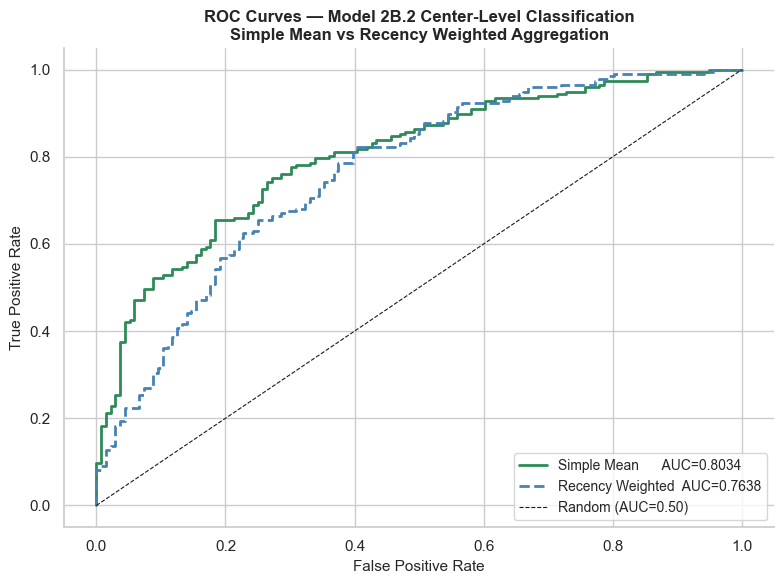

Saved: m2b_roc_center.png


In [47]:
# ROC curve comparing simple mean vs recency weighted aggregation at center level
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 6))

fpr_s, tpr_s, _ = roc_curve(center_labels.loc[common_ids], center_clf_simple.loc[common_ids])
ax.plot(fpr_s, tpr_s, color='seagreen', linewidth=2,
        label=f'Simple Mean      AUC={auc_2b_simple:.4f}')

fpr_r, tpr_r, _ = roc_curve(center_labels.loc[common_ids], center_clf_recency.loc[common_ids])
ax.plot(fpr_r, tpr_r, color='steelblue', linewidth=2, linestyle='--',
        label=f'Recency Weighted  AUC={auc_2b_recency:.4f}')

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random (AUC=0.50)')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — Model 2B.2 Center-Level Classification\n'
             'Simple Mean vs Recency Weighted Aggregation',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, 'm2b_roc_center.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: m2b_roc_center.png')

Simple mean (AUC=0.8034) consistently outperforms recency weighted aggregation (AUC=0.7638) across the full range of classification thresholds — the advantage is not specific to one operating point. Both aggregation methods substantially outperform random classification. The consistent gap confirms that simple mean is the more reliable aggregation method for this dataset, where only 5 reviews per center are available and recency weighting amplifies noise rather than improving signal.

### 4.2 Model 2B.2 — Predicted vs Actual (Center-Level Regression)

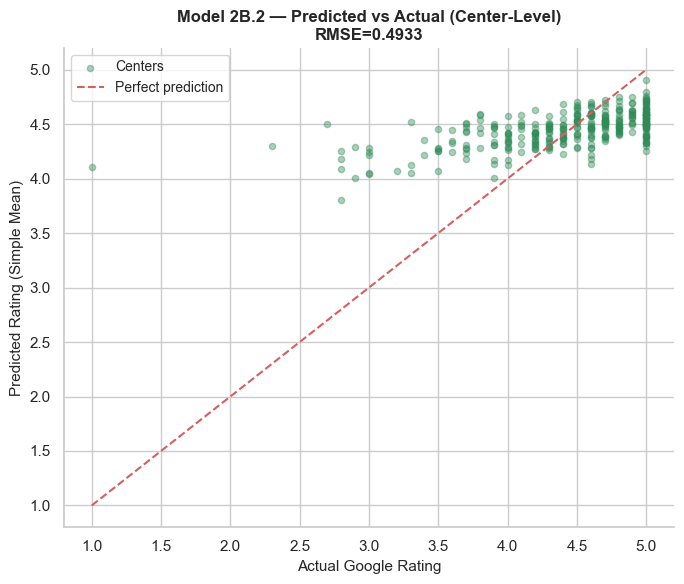

Saved: m2b_scatter_center.png


In [48]:
# Predicted vs actual scatter — center-level regression (simple mean aggregation)
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(center_ratings.loc[common_ids], center_reg_simple.loc[common_ids],
           alpha=0.4, s=20, color='seagreen', label='Centers')
ax.plot([1, 5], [1, 5], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Google Rating', fontsize=11)
ax.set_ylabel('Predicted Rating (Simple Mean)', fontsize=11)
ax.set_title(f'Model 2B.2 — Predicted vs Actual (Center-Level)\n'
             f'RMSE={rmse_2b_simple:.4f}',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, 'm2b_scatter_center.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: m2b_scatter_center.png')

Predictions track the diagonal in the 4.0 to 5.0 range, but compression is more pronounced than in Model 2A (RMSE=0.4477). This is expected — individual review predictions carry more noise than center-level aggregated text, and averaging 5 predictions per center only partially smooths that noise. Centers rated between 1.0 and 3.0 stars are still pushed toward 4.0 to 4.5, though less severely than Model 1 where all predictions collapsed to a flat 4.0 to 4.7 band. Model 2B.2 sits between Model 1 and Model 2A in both RMSE and visual discrimination quality.

### 4.3 Model 2B.2 — Word Predictors: Center-Level Quality

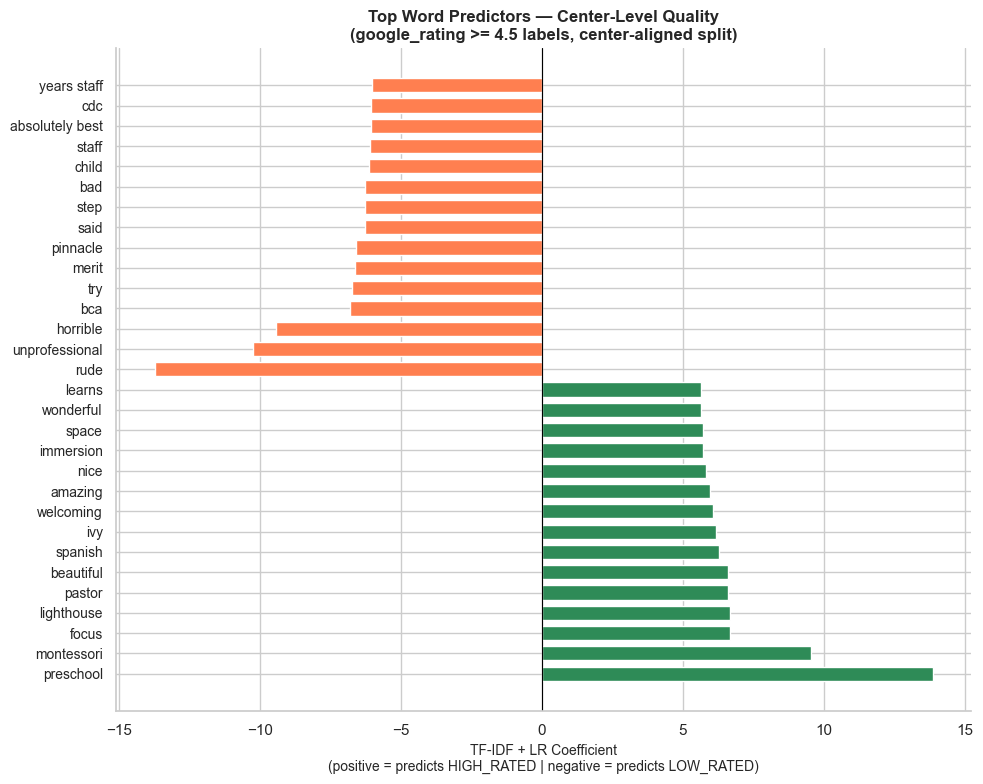

Saved: m2b_word_coef_center.png


In [49]:
# Top 15 TF-IDF + LR coefficients for center-level quality classification
# Labels: google_rating >= 4.5 (same as Model 1), center-aligned split
feature_names_2b2 = m2b_grid_clf.best_estimator_.named_steps['tfidf'].get_feature_names_out()
coefficients_2b2  = m2b_grid_clf.best_estimator_.named_steps['clf'].coef_[0]

N = 15
top_pos_idx = coefficients_2b2.argsort()[-N:][::-1]
top_neg_idx = coefficients_2b2.argsort()[:N]

top_words = list(feature_names_2b2[top_pos_idx]) + list(feature_names_2b2[top_neg_idx])
top_coefs = list(coefficients_2b2[top_pos_idx]) + list(coefficients_2b2[top_neg_idx])
colors    = ['seagreen' if c > 0 else 'coral' for c in top_coefs]

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = range(len(top_words))
ax.barh(list(y_pos), top_coefs, color=colors, edgecolor='white', height=0.7)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(top_words, fontsize=10)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('TF-IDF + LR Coefficient\n(positive = predicts HIGH_RATED | negative = predicts LOW_RATED)',
              fontsize=10)
ax.set_title('Top Word Predictors — Center-Level Quality\n'
             '(google_rating >= 4.5 labels, center-aligned split)',
             fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, 'm2b_word_coef_center.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: m2b_word_coef_center.png')

**Word Predictors — Center-Level Quality**

"preschool" and "montessori" are the two strongest positive predictors — the same top words found in Notebook 02 Model 2A. This consistency across two different modeling approaches (center-level aggregated text vs individual review center-aligned text) validates that program identity is a genuine and robust signal of center quality.

On the negative side, "rude", "unprofessional", and "horrible" again dominate — the same vocabulary found across all three text models in this project. Staff behavior complaints are the most reliable negative signal regardless of how the text is processed.

Several negative predictors appear to be center names or acronyms ("bca", "cdc", "pinnacle", "merit", "lighthouse", "ivy"). These terms appear in reviews that name specific centers directly. The model has learned that reviews mentioning these names are associated with lower center ratings — a form of center identity memorisation rather than generalizable quality signal. This is a known limitation of the center-aligned split where all reviews from one center remain in the same train or test partition.

"staff" appears as a negative predictor here, in contrast to Notebook 02 where it was positive. In center-aligned reviews labeled with center quality, "staff" frequently appears in negative context — "the staff was rude", "the staff did not communicate" — pulling the coefficient negative for centers with poor aggregate ratings.

## 5. Model 2B.2 — Center-Level Error Analysis

Identifies which centers the Model 2B.2 classifier (TF-IDF + LR, center-aligned split, google_rating >= 4.5 labels) misclassified after aggregation. Centers predicted HIGH_RATED but actually LOW_RATED are the most consequential errors for parents — they would receive no warning about a poor-quality center. Centers predicted LOW_RATED but actually HIGH_RATED generate unnecessary concern about a good center.

### 5.1 Model 2B.2 — Misclassified Centers (Simple Mean)

In [52]:
# Classify centers at threshold 0.5 using simple mean aggregation
pred_labels_2b2 = (center_clf_simple.loc[common_ids] >= 0.5).astype(int)
true_labels_2b2 =  center_labels.loc[common_ids]

fp_ids = [cid for cid in common_ids if pred_labels_2b2[cid] == 1 and true_labels_2b2[cid] == 0]
fn_ids = [cid for cid in common_ids if pred_labels_2b2[cid] == 0 and true_labels_2b2[cid] == 1]

total = len(common_ids)
print(f'Total centers: {total}')
print(f'False positives (predicted HIGH_RATED, actually LOW_RATED): {len(fp_ids)} '
      f'({len(fp_ids)/total*100:.1f}%)')
print(f'False negatives (predicted LOW_RATED, actually HIGH_RATED): {len(fn_ids)} '
      f'({len(fn_ids)/total*100:.1f}%)')

Total centers: 333
False positives (predicted HIGH_RATED, actually LOW_RATED): 52 (15.6%)
False negatives (predicted LOW_RATED, actually HIGH_RATED): 37 (11.1%)


### 5.2 Model 2B.2 — Center-Level Confusion Matrix

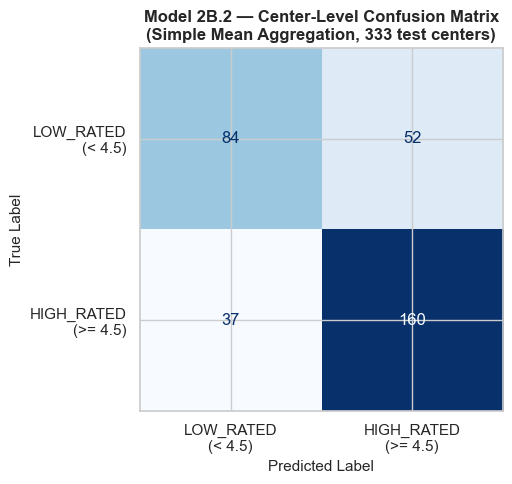

Saved: m2b_confusion_center.png


In [53]:
# Center-level confusion matrix for Model 2B.2 (simple mean aggregation)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(true_labels_2b2, pred_labels_2b2),
    display_labels=['LOW_RATED\n(< 4.5)', 'HIGH_RATED\n(>= 4.5)']
)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Model 2B.2 — Center-Level Confusion Matrix\n'
             '(Simple Mean Aggregation, 333 test centers)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, 'm2b_confusion_center.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: m2b_confusion_center.png')

**Confusion Matrix — Inference**

The model correctly identifies 84 of 136 LOW_RATED centers (62% recall) and 160 of 197 HIGH_RATED centers (81% recall).

**Comparison to Model 1:**

- Model 1 missed 56 LOW_RATED centers (41% of all poor centers)
- Model 2B.2 misses 52 LOW_RATED centers (38% of all poor centers)
- Text beats compliance even on the hardest metric — identifying poor quality centers

**Why the 52 false positives occur:**

- The 5 review API cap means a low rated center might have 3 to 4 genuinely positive recent reviews in its returned data, pulling the predicted probability above 0.5 while older negative reviews remain invisible
- Centers near the 4.5 star threshold are inherently ambiguous — a center rated 4.3 stars is genuinely good and its reviews read positively, making correct classification at the boundary difficult
- Label noise from center-aligned training means some positive language in low rated center reviews was partially learned as a quality signal

**Bottom line:** The text model misses fewer poor centers than compliance records do, and its remaining failures have a structural explanation. With more reviews per center, performance would improve.

## 6. Save Outputs — Handoff to Notebook 04

Saves all Model 2B.2 results to `model2b_outputs.pkl` for use by Notebook 04. Includes center-level regression and classification metrics for both aggregation methods, center-level true labels, predicted probabilities, and common center IDs for the final cross-model comparison.

In [56]:
# ── Save Model 2B outputs (pickle) ──────────────────────────────────────
m2b_outputs = {
    "rmse_2b_recency": float(rmse_2b_recency), "rmse_2b_simple": float(rmse_2b_simple),
    "r2_2b_simple":   float(r2_2b_simple),   "r2_2b_recency":  float(r2_2b_recency),
    "auc_2b_recency":  float(auc_2b_recency),  "auc_2b_simple":  float(auc_2b_simple),
    "center_labels":      center_labels,
    "center_clf_simple":  center_clf_simple,
    "common_ids":         common_ids,
}
with open(os.path.join(PROC_DIR, "model2b_outputs.pkl"), "wb") as f:
    pickle.dump(m2b_outputs, f)
print("Model 2B outputs saved -> data/processed/model2b_outputs.pkl")
print(f"  rmse_2b_simple   : {rmse_2b_simple:.4f}  (recency: {rmse_2b_recency:.4f})")
print(f"  r2_2b_simple     : {r2_2b_simple:.4f}   (recency: {r2_2b_recency:.4f})")
print(f"  auc_2b_simple    : {auc_2b_simple:.4f}   (recency: {auc_2b_recency:.4f})")
print(f"  center_labels    : {len(center_labels):,} centers")
print(f"  center_clf_simple: {len(center_clf_simple):,} centers")
print(f"  common_ids       : {len(common_ids):,} centers (used for cross-model comparison)")


Model 2B outputs saved -> data/processed/model2b_outputs.pkl
  rmse_2b_simple   : 0.4933  (recency: 0.4964)
  r2_2b_simple     : 0.2597   (recency: 0.2504)
  auc_2b_simple    : 0.8034   (recency: 0.7638)
  center_labels    : 333 centers
  center_clf_simple: 333 centers
  common_ids       : 333 centers (used for cross-model comparison)
